In [19]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import string
import os
from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## 2 RNN

### Data Preprocessing

In [20]:
def clean_word(word):
    word = word.lower()
    word = word.strip()
    word = word.translate(str.maketrans('', '', string.punctuation))
    return word if len(word) > 1 else None

In [21]:
NEW_CORPUS = True
NUMBER_OF_BOOKS = 5

In [22]:
# Read the .txt files
if not os.path.exists('whole_text.txt') or NEW_CORPUS:
    whole_text = []
    i = 0
    for filename in os.listdir('GOT'):
        if filename.endswith('.txt'):
            with open(os.path.join('GOT', filename), encoding='cp1252') as file:
                for line in file:
                    words = word_tokenize(line)
                    if words:
                        for word in words:
                            cleaned_word = clean_word(word)
                            if cleaned_word:
                                whole_text.append(cleaned_word)
        if i >= NUMBER_OF_BOOKS-1:
            break
        i += 1
    with open('whole_text.txt', 'w', encoding='utf-8') as f:
        for word in whole_text:
            f.write(word + '\n')
else:
    with open('whole_text.txt', 'r') as file:
        whole_text = file.read().splitlines()
whole_text[:10]

['game', 'of', 'thrones', 'book', 'one', 'of', 'song', 'of', 'ice', 'and']

### Create corpus

In [23]:
unique_tokens = set(whole_text)
print(f"Number of unique tokens: {len(unique_tokens)}")

Number of unique tokens: 26689


In [24]:
word2idx = {word: idx for idx, word in enumerate(unique_tokens)}
idx2word = {idx: word for word, idx in word2idx.items()}

In [25]:
def generate_sequences(tokens, n=5):
    sequences = []
    for i in range(len(tokens) - n + 1):
        seq = tokens[i:i + n - 1]
        target = tokens[i + n - 1]
        sequences.append((seq, target))
    return sequences

In [26]:
corpus = generate_sequences(whole_text, n=5)
print(corpus[:3])


[(['game', 'of', 'thrones', 'book'], 'one'), (['of', 'thrones', 'book', 'one'], 'of'), (['thrones', 'book', 'one', 'of'], 'song')]


### Create Dataset and Dataloader

In [27]:
class CorpusDataset(Dataset):
    def __init__(self, corpus, word2idx):
        self.corpus = corpus
        self.word2idx = word2idx

    def __len__(self):
        return len(self.corpus)

    def __getitem__(self, idx):
        seq, target = self.corpus[idx]
        seq_idx = [self.word2idx[word] for word in seq]
        target_idx = self.word2idx[target]
        return torch.tensor(seq_idx, dtype=torch.long), torch.tensor(target_idx, dtype=torch.long)

In [28]:
got_dataset = CorpusDataset(corpus, word2idx)
got_dataset_len = len(got_dataset)
trainingset_len = int(0.8 * got_dataset_len)
validationset_len = int(0.1 * got_dataset_len)
testset_len = got_dataset_len - trainingset_len - validationset_len
train_set, val_set, test_set = torch.utils.data.random_split(got_dataset, [trainingset_len, validationset_len, testset_len])
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

### Build the model

In [29]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(RNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.linear(out[:, -1, :])
        return out

In [30]:
def validate_rnn(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for sequences, targets in tqdm(val_loader, desc="Validation"):
            sequences = sequences.to(device)
            targets = targets.to(device)
            
            outputs = model(sequences)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    
    validation_loss = total_loss / len(val_loader)
    return validation_loss

In [31]:
def plot_loss(train_losses, val_losses):
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def train_rnn(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    model.to(device)
    min_validation_loss = float('inf')
    average_loss_per_epoch = []
    validation_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        train_loader = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")
        for i, (sequences, targets) in enumerate(train_loader):
            sequences = sequences.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()

            train_loader.set_postfix({"loss": total_loss / (i + 1)})
        average_loss_per_epoch.append(total_loss / len(train_loader))
        
        validation_loss = validate_rnn(model, val_loader, criterion, device)<
        validation_losses.append(validation_loss)
        if validation_loss < min_validation_loss:
            min_validation_loss = validation_loss
            torch.save(model.state_dict(), 'best_rnn.pth')
            print(f"Validation loss improved to {min_validation_loss:.4f}, model saved.")
    plot_loss(average_loss_per_epoch, validation_losses)
    return total_loss / len(train_loader)

In [33]:
# HYPERPARAMETERS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBEDDING_DIM = 16
HIDDEN_DIM = 16
VOCAB_SIZE = len(word2idx)
LEARNING_RATE = 0.001
EPOCHS = 20

In [34]:
rnn = RNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=LEARNING_RATE)

In [35]:
print(f"Training on {NUMBER_OF_BOOKS} book{'s' if NUMBER_OF_BOOKS > 1 else ''} with {len(unique_tokens)} unique tokens.")

Training on 5 books with 26689 unique tokens.


Validation: 100%|██████████| 5391/5391 [00:02<00:00, 1811.16it/s]


Validation loss improved to 6.2379, model saved.


Validation: 100%|██████████| 5391/5391 [00:02<00:00, 1811.50it/s]


Validation loss improved to 6.1694, model saved.


Validation: 100%|██████████| 5391/5391 [00:02<00:00, 1856.02it/s]


...

Validation: 100%|██████████| 5391/5391 [00:03<00:00, 1702.08it/s]


Validation loss improved to 6.0635, model saved.


Validation: 100%|██████████| 5391/5391 [00:02<00:00, 1870.43it/s]


Validation loss improved to 6.0618, model saved.


Validation: 100%|██████████| 5391/5391 [00:02<00:00, 1863.51it/s]


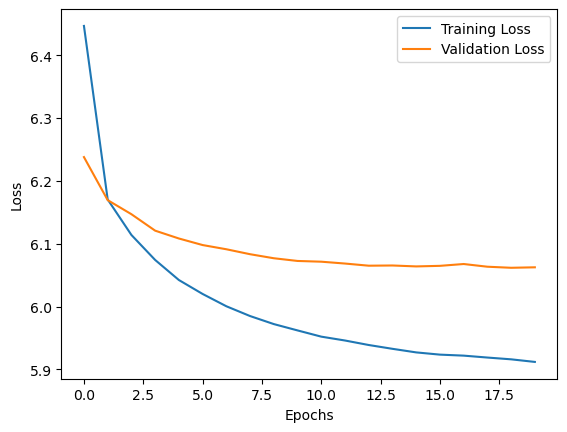

5.911997376188907

In [36]:
train_rnn(
    model=rnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=DEVICE
)

In [37]:
rnn.load_state_dict(torch.load('best_rnn.pth'))

<All keys matched successfully>

In [38]:
def evaluate(model, test_loader):
    model.to(DEVICE)
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for embeddings, labels in tqdm(test_loader, desc="Testing"):
            embeddings = embeddings.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(embeddings)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    
    return accuracy_score(y_true, y_pred)

In [39]:
print(f"Test Accuracy: {evaluate(rnn, test_loader):.4f}")

Testing: 100%|██████████| 5391/5391 [00:02<00:00, 1849.78it/s]


Test Accuracy: 0.1238


In [40]:
examples_text = [
    ["jon", "snow", "looked", "at"],
    ["daenerys", "targaryen", "was", "the"],
    ["tyrion", "lannister", "knew", "that"],
    ["arya", "stark", "was", "not"],
    ["sansa", "stark", "had", "to"]
]
examples = [[clean_word(word) for word in example if clean_word(word) in word2idx] for example in examples_text]
print(f"Examples: {examples}")
examples = [[word2idx[word] for word in example] for example in examples]
output = rnn(torch.tensor(examples, dtype=torch.long).to(DEVICE))
_, top_indices = torch.topk(output, 3)
print(f"top indices: {top_indices}")
top_indices = [indices.tolist() for indices in top_indices.to('cpu')]
print(f"top indices: {top_indices}")
predictions = [[idx2word[idx] for idx in indices] for indices in top_indices]
for i, example in enumerate(examples_text):
    print(f"Input: {' '.join(example)}")
    print(f"Predictions: {', '.join(predictions[i])}")
    print()

Examples: [['jon', 'snow', 'looked', 'at'], ['daenerys', 'targaryen', 'was', 'the'], ['tyrion', 'lannister', 'knew', 'that'], ['arya', 'stark', 'was', 'not'], ['sansa', 'stark', 'had', 'to']]
top indices: tensor([[12751, 17096, 24632],
        [ 5077,  6342,  1743],
        [ 5310, 12751, 18477],
        [ 8406, 21808,  5777],
        [12751,  7555, 17096]], device='cuda:0')
top indices: [[12751, 17096, 24632], [5077, 6342, 1743], [5310, 12751, 18477], [8406, 21808, 5777], [12751, 7555, 17096]]
Input: jon snow looked at
Predictions: the, her, him

Input: daenerys targaryen was the
Predictions: man, same, king

Input: tyrion lannister knew that
Predictions: he, the, was

Input: arya stark was not
Predictions: as, to, so

Input: sansa stark had to
Predictions: the, be, her

